In [1]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load the audio file
audio_file = './dataset/train/Drone/5m-50m-ex6.wav'  # Replace with your audio file path
y_audio, sr = librosa.load(audio_file)  # , duration=20)

y_audio = y_audio[:66000]
timesDuration = librosa.get_duration(y=y_audio, sr=sr)

# normalize audio  
max_value = np.max(np.abs(y_audio))       # Determine the maximum values
audio_normalize = y_audio/max_value        # Use max_value and normalize sound data to get values between -1 & +1


print(f'Sampling Rate: {sr} Hz')
print(f'Audio Duration: {timesDuration:.0f} seconds')

Sampling Rate: 22050 Hz
Audio Duration: 3 seconds


In [3]:
from IPython.display import Audio 
Audio(data=audio_normalize, rate=sr)

Configure the STFT

In [4]:
# Configure the STFT
def spectrogram_cal(data):
    n_fft = 2048       # Length of FFT window
    hop_length = 512   # Number of samples between frames
    win_length = 2048  # Length of the window
    window = 'hann'    # Windowing function

    # Compute the STFT
    spectrogram = librosa.stft(data, n_fft=n_fft, hop_length=hop_length, win_length=win_length, window=window)
    spectrogram_db = librosa.amplitude_to_db(np.abs(spectrogram))  # Convert to dB
    
    return spectrogram_db

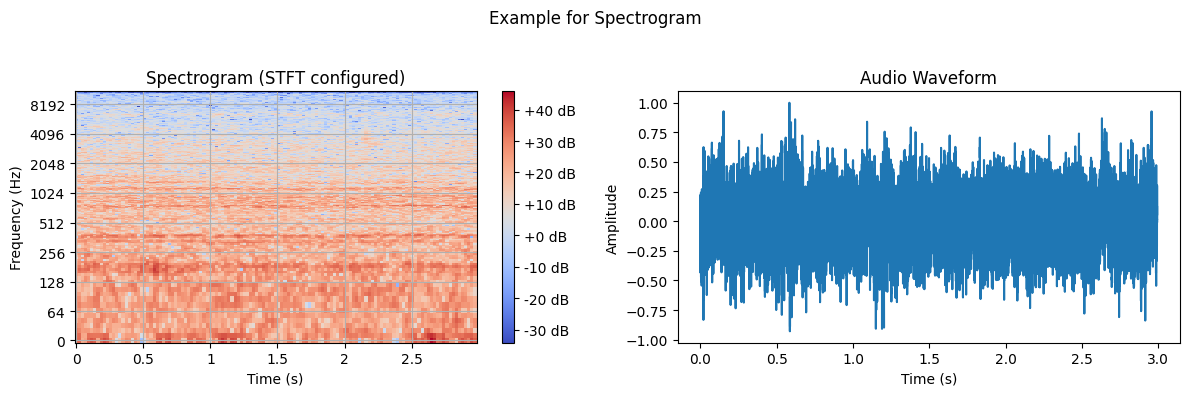

In [5]:
# calurate Spectrogram
Audio = audio_normalize
spectrogram_db = spectrogram_cal(Audio)

# Plot Spectrogram
plt.figure(figsize=(12, 4))
plt.suptitle(f'Example for Spectrogram')
plt.subplot(1, 2, 1)
plt.title(f'Spectrogram')
librosa.display.specshow(spectrogram_db, sr=sr, x_axis='time', y_axis='log', cmap='coolwarm')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram (STFT configured)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.grid()
#cmap = 'viridis', 'plasma', 'inferno', 'magma', 'cividis'

plt.subplot(1, 2, 2)
plt.title(f'Audio Waveform')
plt.plot(np.linspace(0, len(Audio) / sr, len(Audio)), Audio)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [6]:
from scipy import signal
from scipy.signal import butter, lfilter, filtfilt # type: ignore

# Audio Filter
def butter_highpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

def butter_highpass_filter(data, cutoff, fs, order=5):
    b, a = butter_highpass(cutoff, fs, order=order)
    y = signal.filtfilt(b, a, data)
    return y

def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

In [7]:
# High Pass filter
freq_cutoff = 1000
audio_HPF = butter_highpass_filter(audio_normalize,freq_cutoff,sr)

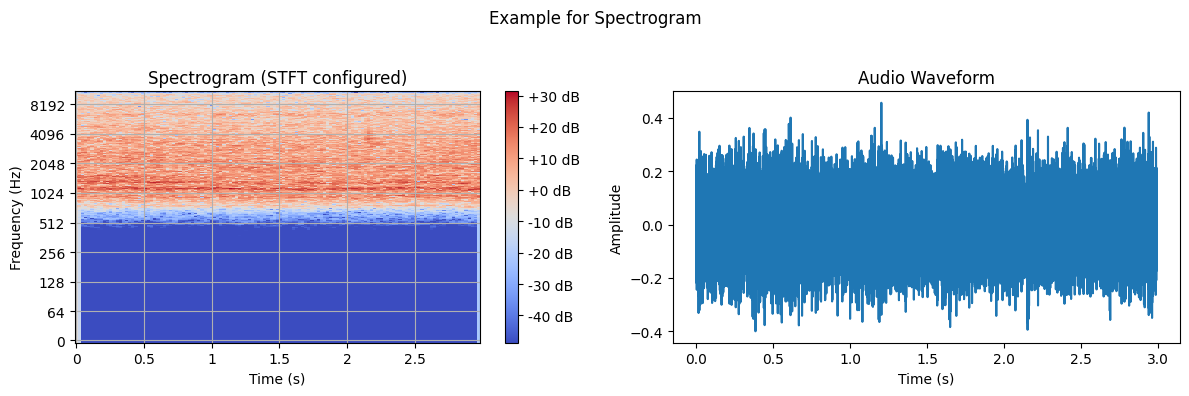

In [8]:
# calurate Spectrogram
Audio = audio_HPF
spectrogram_db = spectrogram_cal(Audio)

# Plot Spectrogram
plt.figure(figsize=(12, 4))
plt.suptitle(f'Example for Spectrogram')
plt.subplot(1, 2, 1)
plt.title(f'Spectrogram')
librosa.display.specshow(spectrogram_db, sr=sr, x_axis='time', y_axis='log', cmap='coolwarm')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram (STFT configured)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.grid()
#cmap = 'viridis', 'plasma', 'inferno', 'magma', 'cividis'

plt.subplot(1, 2, 2)
plt.title(f'Audio Waveform')
plt.plot(np.linspace(0, len(Audio) / sr, len(Audio)), Audio)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Noise Reduce

Shape of spectrogram (1025, 129)


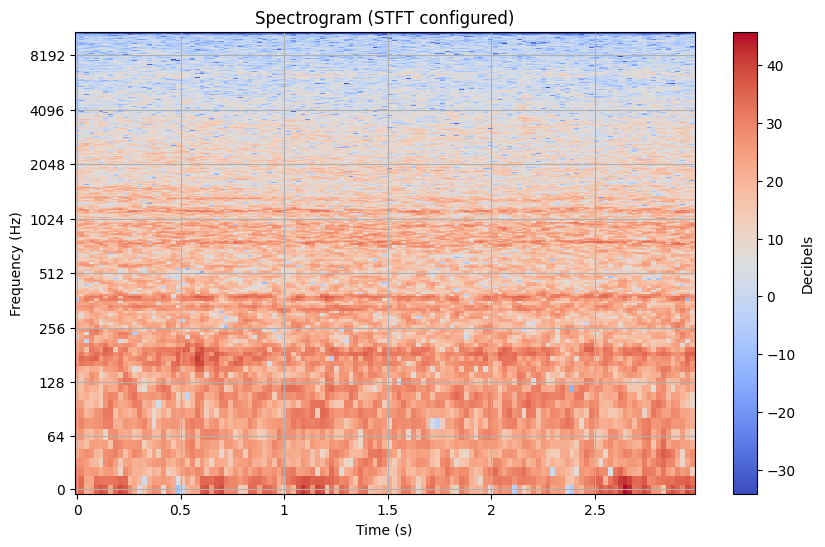

In [9]:
# Configure the STFT
n_fft = 2048       # Length of FFT window
hop_length = 512   # Number of samples between frames
win_length = 2048  # Length of the window
window = 'hann'    # Windowing function

# Compute the STFT
spectrogram = librosa.stft(audio_normalize, n_fft=n_fft, hop_length=hop_length, win_length=win_length, window=window)
spectrogram_db = librosa.amplitude_to_db(np.abs(spectrogram))  # Convert to dB

print("Shape of spectrogram " + str(spectrogram.shape))

# Plot the spectrogram
plt.figure(figsize=(10, 6))
librosa.display.specshow(spectrogram_db, sr=sr, x_axis='time', y_axis='log', cmap='coolwarm')
plt.colorbar(label='Decibels')
plt.title('Spectrogram (STFT configured)')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.grid()

# Show plots
plt.show()